# Importing Data

Membaca dataset dari file CSV atau Excel menggunakan pandas.read_csv() atau pandas.read_excel().


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

data = pd.read_csv(r"C:\Users\MSI1\Downloads\Caffe Sales.csv")
df = pd.DataFrame(data)
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


# Data Exploration
Mengeksplorasi data menggunakan fungsi seperti head(), info(), describe(), distribusi data, dan memeriksa tipe data,serta  jumlah missing value.

In [2]:
# Menampilkan 50 data teratas untuk melihat data yang kosong
df.head(50)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


Melihat data yang tidak null atau tidak kosong

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


Melihat statistik deskriptif, dari data yang tidak kosong, total isi data dari setiap kolom, dan nilai tertinggi dengan jumlahnya

In [4]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


Menampilkan distribusi data ke kolom yang mempunyai nilai tertentu

Sebelum itu, data harus diubah terlebih dahulu

In [5]:
# Mengubah tipe data yang perlu diubah
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').astype('Int64')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce').astype('float64')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce').astype('float64')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

df.dtypes

Transaction ID              object
Item                        object
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

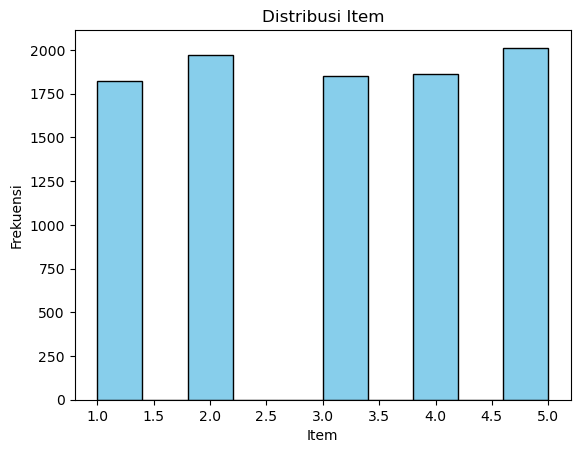

In [6]:
# Menampilkan histogram untuk melihat distribusi Quantity
plt.hist(df['Quantity'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribusi Item')
plt.xlabel('Item')
plt.ylabel('Frekuensi')
plt.show()

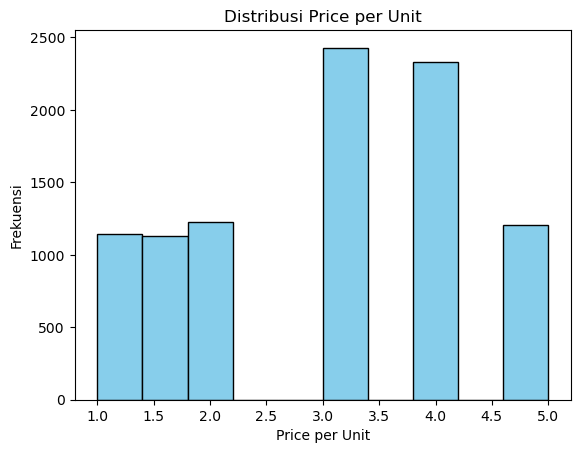

In [7]:
# Menampilkan histogram untuk melihat distribusi Price per Unit
plt.hist(df['Price Per Unit'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribusi Price per Unit')
plt.xlabel('Price per Unit')
plt.ylabel('Frekuensi')
plt.show()

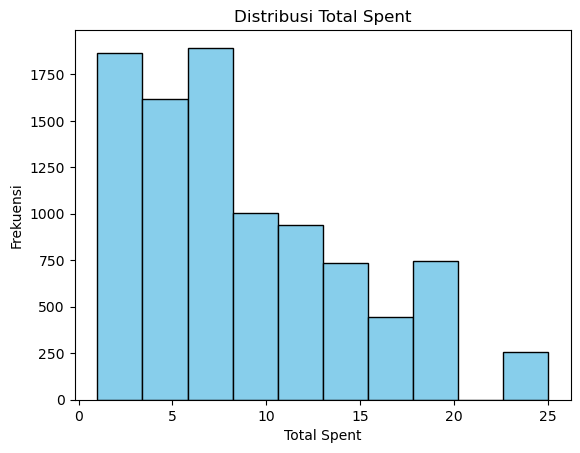

In [8]:
# Menampilkan histogram untuk melihat distribusi Total Spent
plt.hist(df['Total Spent'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribusi Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frekuensi')
plt.show()

Melihat tipe data

In [9]:
df.dtypes

Transaction ID              object
Item                        object
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

Menghitung semua missing value pada setiap kolom

In [10]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     460
dtype: int64

# Data Cleaning
- Menangani missing values (menghapus atau mengisi dengan nilai tertentu).
- Menghapus duplikat data dan memperbaiki inkonsistensi format (misalnya huruf besar/kecil, spasi berlebih).
- Mengidentifikasi dan menangani outliers (menggunakan metode IQR atau z-score).

In [11]:
# buat semua status seperti <NA>, nan, UNKNOWN, nan, dan ERROR menjadi tipe2 null
df.replace(['<NA>', 'nan', 'UNKNOWN', 'ERROR'], pd.NA, inplace=True)


In [12]:
# Menghitung jumlah missing value di transaction date
df['Transaction Date'].isnull().sum()

np.int64(460)

In [13]:
# Menghapus missing value di transaction date
df = df.dropna(subset=['Transaction Date']).copy()
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,<NA>,<NA>,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,<NA>,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


Sebelumnya sudah diketahui jika:
- COOKIE 1
- TEA 1.5
- COFFEE 2
- CAKE 3
- JUICE 3
- SMOOTHIE 4
- SANDWICH 4
- SALAD 5

In [14]:
# Dictionary harga berdasarkan item
listharga = {
    'Cookie': 1.0,
    'Tea': 1.5,
    'Coffee': 2.0,
    'Cake': 3.0,
    'Juice': 3.0,
    'Smoothie': 4.0,
    'Sandwich': 4.0,
    'Salad': 5.0
}

# 1. Isi Price Per Unit yang kosong berdasarkan Item
mask_price_from_item = (
    df['Price Per Unit'].isnull() &
    df['Item'].notnull()
)

df.loc[mask_price_from_item, 'Price Per Unit'] = (
    df.loc[mask_price_from_item, 'Item'].map(listharga)
)


# 2. Isi Price Per Unit yang kosong berdasarkan Total Spent / Quantity
mask_price_from_total = (
    df['Price Per Unit'].isnull() &
    df['Total Spent'].notnull() &
    df['Quantity'].notnull() &
    (df['Quantity'] != 0)
)

df.loc[mask_price_from_total, 'Price Per Unit'] = (
    df.loc[mask_price_from_total, 'Total Spent'] /
    df.loc[mask_price_from_total, 'Quantity']
)


# 3. Isi Total Spent yang kosong berdasarkan Quantity * Price Per Unit
mask_total = (
    df['Total Spent'].isnull() &
    df['Quantity'].notnull() &
    df['Price Per Unit'].notnull()
)

df.loc[mask_total, 'Total Spent'] = (
    df.loc[mask_total, 'Quantity'] *
    df.loc[mask_total, 'Price Per Unit']
)


# 4. Isi Quantity yang kosong berdasarkan Total Spent / Price Per Unit
mask_quantity = (
    df['Quantity'].isnull() &
    df['Total Spent'].notnull() &
    df['Price Per Unit'].notnull() &
    (df['Price Per Unit'] != 0)
)

df.loc[mask_quantity, 'Quantity'] = (
    df.loc[mask_quantity, 'Total Spent'] /
    df.loc[mask_quantity, 'Price Per Unit']
)

Selanjutnya, mensamakan nilai harga dengan item untuk memastikan tidak ada nilai null yang tersisa dan dimulai dari harga yang tidak sama terlebih dahulu

In [15]:
# Dictionary item berdasarkan harga yang hanya punya 1 kemungkinan item
list1item = {
    1.0: "Cookie",
    1.5: "Tea",
    2.0: "Coffee",
    5.0: "Salad"
}

# Isi Item yang kosong jika Price Per Unit sudah diketahui
mask_item = (
    df['Item'].isnull() &
    df['Price Per Unit'].isin(list1item.keys())
)

df.loc[mask_item, 'Item'] = (
    df.loc[mask_item, 'Price Per Unit'].map(list1item)
)

df[(df['Item'].isnull()) &(df['Price Per Unit'].notnull()) & ((df['Price Per Unit'] == 3.0) | (df['Price Per Unit'] == 4.0))]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
6,TXN_4433211,<NA>,3,3.0,9.0,<NA>,Takeaway,2023-10-06
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
36,TXN_6855453,<NA>,4,3.0,12.0,NaN,In-store,2023-07-17
61,TXN_8051289,NaN,1,3.0,3.0,NaN,In-store,2023-10-09
69,TXN_8471743,<NA>,5,3.0,15.0,Digital Wallet,In-store,2023-04-06
...,...,...,...,...,...,...,...,...
9910,TXN_2338617,<NA>,2,3.0,6.0,Digital Wallet,<NA>,2023-01-12
9918,TXN_2292088,<NA>,1,4.0,4.0,Digital Wallet,Takeaway,2023-03-04
9946,TXN_8807600,<NA>,1,4.0,4.0,Cash,Takeaway,2023-09-24
9981,TXN_4583012,<NA>,5,4.0,20.0,Digital Wallet,NaN,2023-02-27


Selanjutnya, membuat sistem untuk nilai 3.0 dan 4.0 yang memiliki 2 item yang berbeda

Untuk nilai 3.0, item yang mungkin adalah Juice atau Cake

Untuk nilai 4.0, item yang mungkin adalah Smoothie atau Sandwich

In [16]:
# Pertama-tama, menghitung total Juice dan total Cake
total_juice = df[df['Item'] == 'Juice']['Quantity'].sum()
total_cake = df[df['Item'] == 'Cake']['Quantity'].sum()

# Kemudian, menghitung total Smoothie dan total Sandwich
total_smoothie = df[df['Item'] == 'Smoothie']['Quantity'].sum()
total_sandwich = df[df['Item'] == 'Sandwich']['Quantity'].sum()

# Lalu menampilkan total untuk melihat seberapa besar perbandingan dari tiap Nilai
print("Total Juice:", total_juice)
print("Total Cake:", total_cake)
print("\nTotal Smoothie:", total_smoothie)
print("Total Sandwich:", total_sandwich)

Total Juice: 3341
Total Cake: 3278

Total Smoothie: 3194
Total Sandwich: 3267


Dikarenakan kedua nilai mempunyai nilai perbandingan yang hampir sama, maka untuk menentukan Item yang mempunyai nilai yang sama, akan digunakan sistem random selection dengan peluang yang sama yaitu 50:50

In [17]:
np.random.seed(42)

# Untuk Price Per Unit 3.0, item kosong akan diisi Cake atau Juice
mask_3 = (df['Item'].isnull() & (df['Price Per Unit'] == 3.0))

df.loc[mask_3, 'Item'] = np.random.choice(['Cake', 'Juice'],size=mask_3.sum())
# Untuk Price Per Unit 4.0, item kosong akan diisi Smoothie atau Sandwich
mask_4 = (df['Item'].isnull() & (df['Price Per Unit'] == 4.0))

df.loc[mask_4, 'Item'] = np.random.choice(['Smoothie', 'Sandwich'],size=mask_4.sum())

In [18]:
# Sistem Diupdate kembali untuk melakukan pengecekan
total_juice = df[df['Item'] == 'Juice']['Quantity'].sum()
total_cake = df[df['Item'] == 'Cake']['Quantity'].sum()

total_smoothie = df[df['Item'] == 'Smoothie']['Quantity'].sum()
total_sandwich = df[df['Item'] == 'Sandwich']['Quantity'].sum()

print("Total Juice:", total_juice)
print("Total Cake:", total_cake)
print("Total Smoothie:", total_smoothie)
print("Total Sandwich:", total_sandwich)

Total Juice: 3689
Total Cake: 3647
Total Smoothie: 3518
Total Sandwich: 3612


Setelah diisi, data dari keempat kolom tersebut (Item, Quantity, Price Per Unit, dan Total Spent) akan dicek kembali mana bagian yang masih kosong

In [19]:
# Menampilkan Quantity yang null
df[(df['Quantity'].isnull())]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
236,TXN_8562645,Salad,<NA>,5.0,NaN,NaN,In-store,2023-05-18
278,TXN_3229409,Juice,<NA>,3.0,NaN,Cash,Takeaway,2023-04-15
641,TXN_2962976,Juice,<NA>,3.0,NaN,NaN,NaN,2023-03-17
738,TXN_8696094,Sandwich,<NA>,4.0,NaN,NaN,Takeaway,2023-05-14
2796,TXN_9188692,Cake,<NA>,3.0,NaN,Credit Card,NaN,2023-12-01
3203,TXN_4565754,Smoothie,<NA>,4.0,NaN,Digital Wallet,Takeaway,2023-10-06
3224,TXN_6297232,Coffee,<NA>,2.0,NaN,NaN,NaN,2023-04-07
3401,TXN_3251829,Tea,<NA>,1.5,NaN,Digital Wallet,In-store,2023-07-25
3779,TXN_7376255,<NA>,<NA>,NaN,25.0,NaN,In-store,2023-05-27
4257,TXN_6470865,Coffee,<NA>,2.0,NaN,Digital Wallet,Takeaway,2023-09-18


In [20]:
# Menampilkan Total Spent yang null
df[(df['Total Spent'].isnull())]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
236,TXN_8562645,Salad,<NA>,5.0,NaN,NaN,In-store,2023-05-18
278,TXN_3229409,Juice,<NA>,3.0,NaN,Cash,Takeaway,2023-04-15
641,TXN_2962976,Juice,<NA>,3.0,NaN,NaN,NaN,2023-03-17
738,TXN_8696094,Sandwich,<NA>,4.0,NaN,NaN,Takeaway,2023-05-14
1761,TXN_3611851,NaN,4,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,<NA>,4,NaN,NaN,<NA>,NaN,2023-12-09
2796,TXN_9188692,Cake,<NA>,3.0,NaN,Credit Card,NaN,2023-12-01
3203,TXN_4565754,Smoothie,<NA>,4.0,NaN,Digital Wallet,Takeaway,2023-10-06
3224,TXN_6297232,Coffee,<NA>,2.0,NaN,NaN,NaN,2023-04-07
3401,TXN_3251829,Tea,<NA>,1.5,NaN,Digital Wallet,In-store,2023-07-25


Dari sini kita bisa mengetahui bahwa nilai kosong pada Quantity dan Total Spent sama.

Selanjutnya nilai kosong pada Item.

In [21]:
# Menampilkan Item null
df[df['Item'].isnull()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1761,TXN_3611851,NaN,4,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,<NA>,4,NaN,NaN,<NA>,NaN,2023-12-09
3779,TXN_7376255,<NA>,<NA>,NaN,25.0,NaN,In-store,2023-05-27
4152,TXN_9646000,<NA>,2,NaN,NaN,NaN,In-store,2023-12-14
7597,TXN_1082717,<NA>,<NA>,NaN,9.0,Digital Wallet,In-store,2023-12-13
9819,TXN_1208561,NaN,<NA>,NaN,20.0,Credit Card,NaN,2023-08-19


In [22]:
# Total Item
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,<NA>,<NA>,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,<NA>,2023-08-30
9996,TXN_9659401,Cookie,3,1.0,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,1.0,3.0,Digital Wallet,NaN,2023-12-02


Dari sini, bisa diketahu bahwa nilai kosong pada Item terbawa juga dengan nilai kosong pada Quantity. Maka dari itu, dikarenakan nilai tidak dapat diisi dengan kolom yang lain, maka akan lebih baik jika bagian itu dihilangkan.

In [23]:
# Hilangkan semua data null dari kolom Item, Quantity, dan Total Spent

df = df.dropna(subset=['Item', 'Quantity', 'Price Per Unit', 'Total Spent']).copy()

# Menampilkan total data setelah dihilangkan
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,<NA>,<NA>,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,<NA>,2023-08-30
9996,TXN_9659401,Cookie,3,1.0,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,1.0,3.0,Digital Wallet,NaN,2023-12-02


Lalu dilanjutkan untuk cleaning bagian Payment Method dan Location

In [24]:
# Menampilkan jumlah dari setiap unique payment method
df['Payment Method'].value_counts()


Payment Method
Digital Wallet    2190
Credit Card       2165
Cash              2154
Name: count, dtype: int64

In [25]:
df['Payment Method'].isnull().sum()

np.int64(3005)

Dengan cara yang sama, untuk data yang kosong di kolom Payment Method, akan digunakan random selection dengan chance yang sama

In [26]:
# data yang kosong di kolom Payment Method, akan digunakan random selection dengan chance yang sama untuk setiap baris pada kolom Payment Method

np.random.seed(42)

# Menentukan baris yang Payment Method-nya kosong
mask_payment = df['Payment Method'].isnull()

# Pilihan metode pembayaran
payment_options = ['Credit Card', 'Cash', 'Digital Wallet']

# Mengisi missing value dengan pilihan random
df.loc[mask_payment, 'Payment Method'] = np.random.choice(payment_options,size=mask_payment.sum())

In [27]:
df['Payment Method'].value_counts()

Payment Method
Credit Card       3201
Cash              3163
Digital Wallet    3150
Name: count, dtype: int64

Dan juga kolom Location

In [28]:
df['Location'].value_counts()

Location
Takeaway    2883
In-store    2861
Name: count, dtype: int64

In [29]:
np.random.seed(42)

# Menentukan baris yang Location-nya kosong
mask_location = df['Location'].isnull()

# Pilihan lokasi
location_options = ['In-store', 'Takeaway']

# Mengisi missing value Location secara random
df.loc[mask_location, 'Location'] = np.random.choice(location_options,size=mask_location.sum())

In [30]:
df['Location'].value_counts()

Location
Takeaway    4764
In-store    4750
Name: count, dtype: int64

Cek apakah data masih mempunyai missing value

In [31]:
df.info()
jumlah_duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)

<class 'pandas.core.frame.DataFrame'>
Index: 9514 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9514 non-null   object        
 1   Item              9514 non-null   object        
 2   Quantity          9514 non-null   Int64         
 3   Price Per Unit    9514 non-null   float64       
 4   Total Spent       9514 non-null   float64       
 5   Payment Method    9514 non-null   object        
 6   Location          9514 non-null   object        
 7   Transaction Date  9514 non-null   datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), float64(2), object(4)
memory usage: 678.2+ KB
Jumlah data duplikat: 0


Berdasarkan hasil pengecekan, tidak ditemukan data duplikat pada dataset akhir.

#### Outlier Detection and Handling

Pada tahap ini dilakukan pengecekan outlier pada kolom numerik, yaitu Quantity, Price Per Unit, dan Total Spent. 
Metode yang digunakan adalah Interquartile Range (IQR), yaitu metode yang mendeteksi outlier berdasarkan batas bawah dan batas atas dari distribusi data.

Rumus yang digunakan:

- Q1 = kuartil pertama
- Q3 = kuartil ketiga
- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Data yang berada di bawah lower bound atau di atas upper bound akan dianggap sebagai outlier.

In [32]:
# Mengecek outlier menggunakan metode IQR
numerical_columns = ['Quantity', 'Price Per Unit', 'Total Spent']

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print("Jumlah outlier:", len(outliers))
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("-" * 30)

Quantity
Jumlah outlier: 0
Lower Bound: -1.0
Upper Bound: 7.0
------------------------------
Price Per Unit
Jumlah outlier: 0
Lower Bound: -1.0
Upper Bound: 7.0
------------------------------
Total Spent
Jumlah outlier: 259
Lower Bound: -8.0
Upper Bound: 24.0
------------------------------


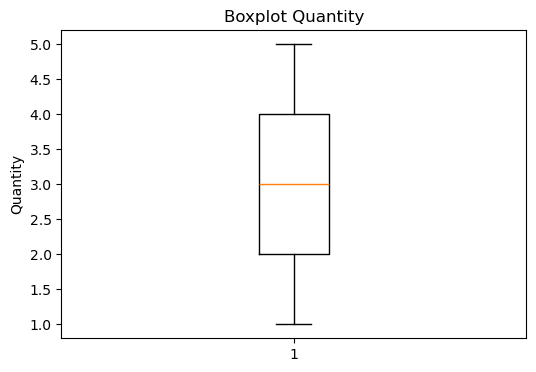

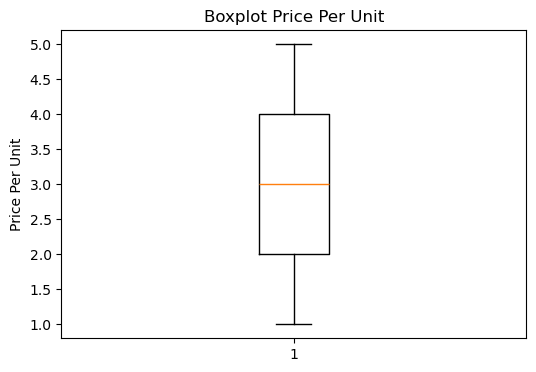

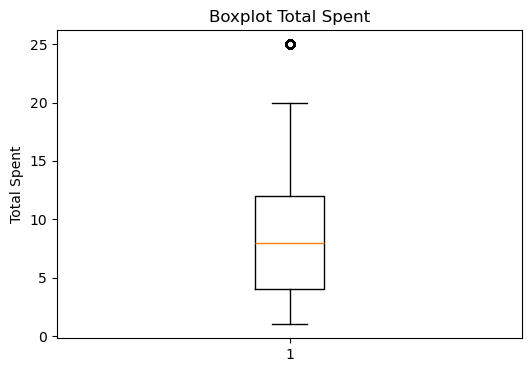

In [33]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot {col}')
    plt.ylabel(col)
    plt.show()

In [34]:
df_capped = df.copy()

for col in numerical_columns:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)

Berdasarkan hasil pengecekan menggunakan metode IQR, outlier hanya ditemukan pada kolom Total Spent sebanyak 259 data. Sementara itu, kolom Quantity dan Price Per Unit tidak memiliki outlier.

Outlier pada Total Spent tidak langsung dihapus karena masih memungkinkan terjadi dalam transaksi, misalnya ketika pelanggan membeli item dengan Quantity tinggi dan Price Per Unit tinggi. Oleh karena itu, penanganan dilakukan menggunakan capping pada dataframe salinan agar data utama tetap aman.

# Data Manipulation
- Menggunakan  type data dengan benar menggunakan type conversion
- Melakukan filtering dan sorting data berdasarkan kondisi tertentu.
- Menggunakan groupby() untuk melakukan agregasi (misal rata-rata penjualan per kategori).
- Membuat kolom baru melalui feature engineering 
- Menormalisasikan data yang mengandung outlier menggunakan Scaling

In [35]:
# Membuat salinan data untuk proses analisis
df_analysis = df.copy()

# Memastikan tipe data sudah sesuai
df_analysis['Quantity'] = df_analysis['Quantity'].astype(int)
df_analysis['Price Per Unit'] = df_analysis['Price Per Unit'].astype(float)
df_analysis['Total Spent'] = df_analysis['Total Spent'].astype(float)
df_analysis['Transaction Date'] = pd.to_datetime(df_analysis['Transaction Date'])

# Menampilkan tipe data akhir
df_analysis.dtypes

Transaction ID              object
Item                        object
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

Feature engineering dilakukan dengan membuat kolom baru dari Transaction Date, yaitu Year, Month, Month Name, dan Day Name. 
Selain itu, dibuat kolom Spending Category untuk mengelompokkan transaksi berdasarkan nilai Total Spent.

In [36]:
# Membuat kolom baru berdasarkan tanggal transaksi
df_analysis['Year'] = df_analysis['Transaction Date'].dt.year
df_analysis['Month'] = df_analysis['Transaction Date'].dt.month
df_analysis['Month Name'] = df_analysis['Transaction Date'].dt.month_name()
df_analysis['Day Name'] = df_analysis['Transaction Date'].dt.day_name()

# Membuat kategori transaksi berdasarkan Total Spent
df_analysis['Spending Category'] = pd.cut(
    df_analysis['Total Spent'],
    bins=[0, 5, 10, 20, df_analysis['Total Spent'].max()],
    labels=['Low', 'Medium', 'High', 'Very High'],
    include_lowest=True
)

df_analysis.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Day Name,Spending Category
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,Low
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,2023,5,May,Tuesday,High
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,2023,7,July,Wednesday,Low
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,In-store,2023-04-27,2023,4,April,Thursday,Medium
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023,6,June,Sunday,Low


#### Filtering

In [37]:
# Menampilkan Filter transaksi bernilai tinggi

high_value_transaction = df_analysis[df_analysis['Total Spent'] >= 20]
high_value_transaction.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Day Name,Spending Category
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,Takeaway,2023-03-31,2023,3,March,Friday,High
9,TXN_2064365,Sandwich,5,4.0,20.0,Digital Wallet,In-store,2023-12-31,2023,12,December,Sunday,High
10,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-11-07,2023,11,November,Tuesday,Very High
20,TXN_3522028,Smoothie,5,4.0,20.0,Cash,In-store,2023-04-04,2023,4,April,Tuesday,High
24,TXN_9400181,Sandwich,5,4.0,20.0,Cash,In-store,2023-06-03,2023,6,June,Saturday,High
28,TXN_8467949,Smoothie,5,4.0,20.0,Credit Card,In-store,2023-03-11,2023,3,March,Saturday,High
51,TXN_6342161,Salad,5,5.0,25.0,Credit Card,Takeaway,2023-01-08,2023,1,January,Sunday,Very High
52,TXN_8914892,Salad,5,5.0,25.0,Digital Wallet,Takeaway,2023-03-15,2023,3,March,Wednesday,Very High
54,TXN_8614868,Smoothie,5,4.0,20.0,Digital Wallet,Takeaway,2023-12-05,2023,12,December,Tuesday,High
96,TXN_5220895,Salad,5,5.0,25.0,Cash,In-store,2023-06-10,2023,6,June,Saturday,Very High


In [38]:
# Menampilkan Filter produk dengan harga tinggi

premium_product_transaction = df_analysis[df_analysis['Price Per Unit'] >= 4.0]
premium_product_transaction.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Day Name,Spending Category
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,In-store,2023-04-27,2023,4,April,Thursday,Medium
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,Takeaway,2023-03-31,2023,3,March,Friday,High
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,In-store,2023-10-28,2023,10,October,Saturday,High
9,TXN_2064365,Sandwich,5,4.0,20.0,Digital Wallet,In-store,2023-12-31,2023,12,December,Sunday,High
10,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-11-07,2023,11,November,Tuesday,Very High
12,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-05-03,2023,5,May,Wednesday,Medium
15,TXN_2847255,Salad,3,5.0,15.0,Credit Card,In-store,2023-11-15,2023,11,November,Wednesday,High
16,TXN_3765707,Sandwich,1,4.0,4.0,Digital Wallet,In-store,2023-06-10,2023,6,June,Saturday,Low
20,TXN_3522028,Smoothie,5,4.0,20.0,Cash,In-store,2023-04-04,2023,4,April,Tuesday,High
21,TXN_3567645,Smoothie,4,4.0,16.0,Credit Card,Takeaway,2023-03-30,2023,3,March,Thursday,High


In [39]:
# Menampilkan Filter transaksi berdasarkan lokasi

instore_transaction = df_analysis[df_analysis['Location'] == 'In-store']
instore_transaction.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Day Name,Spending Category
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,2023,5,May,Tuesday,High
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,2023,7,July,Wednesday,Low
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,In-store,2023-04-27,2023,4,April,Thursday,Medium
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023,6,June,Sunday,Low
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,In-store,2023-10-28,2023,10,October,Saturday,High


Filtering digunakan untuk mengambil data berdasarkan kondisi tertentu. 

Pada bagian ini, filtering dilakukan untuk melihat transaksi bernilai tinggi, produk dengan harga tinggi, serta transaksi berdasarkan lokasi. Hal ini berguna untuk memahami pola transaksi yang paling berkontribusi terhadap revenue.

#### Sorting

In [40]:
# Mengurutkan transaksi berdasarkan Total Spent tertinggi
top_transactions = df_analysis.sort_values(by='Total Spent', ascending=False)

top_transactions.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Day Name,Spending Category
4561,TXN_7442492,Salad,5,5.0,25.0,Credit Card,Takeaway,2023-07-23,2023,7,July,Sunday,Very High
6373,TXN_3212317,Salad,5,5.0,25.0,Cash,Takeaway,2023-05-25,2023,5,May,Thursday,Very High
6844,TXN_1759314,Salad,5,5.0,25.0,Cash,In-store,2023-08-23,2023,8,August,Wednesday,Very High
557,TXN_1183995,Salad,5,5.0,25.0,Digital Wallet,Takeaway,2023-03-28,2023,3,March,Tuesday,Very High
4639,TXN_6369590,Salad,5,5.0,25.0,Digital Wallet,Takeaway,2023-10-26,2023,10,October,Thursday,Very High
7570,TXN_4155770,Salad,5,5.0,25.0,Cash,In-store,2023-09-20,2023,9,September,Wednesday,Very High
1055,TXN_1413304,Salad,5,5.0,25.0,Cash,Takeaway,2023-03-17,2023,3,March,Friday,Very High
5175,TXN_4417257,Salad,5,5.0,25.0,Digital Wallet,Takeaway,2023-05-06,2023,5,May,Saturday,Very High
4630,TXN_6536418,Salad,5,5.0,25.0,Credit Card,In-store,2023-02-11,2023,2,February,Saturday,Very High
570,TXN_2392263,Salad,5,5.0,25.0,Digital Wallet,Takeaway,2023-02-08,2023,2,February,Wednesday,Very High


Sorting digunakan untuk mengurutkan data berdasarkan Total Spent tertinggi. 
Dengan cara ini, transaksi dengan nilai pembelian terbesar dapat dianalisis lebih lanjut.

#### Groupby

Groupby digunakan untuk mengelompokkan data berdasarkan kategori tertentu. 

Pada analisis ini, groupby digunakan untuk melihat performa penjualan berdasarkan Item, Payment Method, dan Location. Hasil agregasi menunjukkan total quantity, total revenue, rata-rata spending, dan jumlah transaksi.

In [41]:
# Revenue per item

item_summary = df_analysis.groupby('Item').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Total Spent', 'sum'),
    Average_Spending=('Total Spent', 'mean'),
    Total_Transaction=('Transaction ID', 'count')
).sort_values(by='Total_Revenue', ascending=False)

item_summary

,Total_Quantity,Total_Revenue,Average_Spending,Total_Transaction
Item,,,,
Salad,3644,18220.0,15.008237,1214
Sandwich,3612,14448.0,12.182125,1186
Smoothie,3518,14072.0,12.268527,1147
Juice,3689,11067.0,8.946645,1237
Cake,3647,10941.0,9.125104,1199
Coffee,3766,7532.0,6.069299,1241
Tea,3441,5161.5,4.523663,1141
Cookie,3427,3427.0,2.982594,1149


In [42]:
# Revenue per payment method

payment_summary = df_analysis.groupby('Payment Method').agg(
    Total_Revenue=('Total Spent', 'sum'),
    Total_Transaction=('Transaction ID', 'count'),
    Average_Spending=('Total Spent', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

payment_summary

,Total_Revenue,Total_Transaction,Average_Spending
Payment Method,,,
Credit Card,28573.5,3201,8.926429
Cash,28296.5,3163,8.946095
Digital Wallet,27998.5,3150,8.888413


In [43]:
# Revenue per location

location_summary = df_analysis.groupby('Location').agg(
    Total_Revenue=('Total Spent', 'sum'),
    Total_Transaction=('Transaction ID', 'count'),
    Average_Spending=('Total Spent', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

location_summary

,Total_Revenue,Total_Transaction,Average_Spending
Location,,,
In-store,42936.0,4750,9.039158
Takeaway,41932.5,4764,8.801952


#### Analisis Tren Bulanan

Analisis tren bulanan dilakukan untuk melihat perubahan revenue dari Januari sampai Desember. 

Hasil ini dapat membantu mengetahui bulan dengan performa penjualan tertinggi dan terendah.

In [44]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_revenue = df_analysis.groupby('Month Name')['Total Spent'].sum().reindex(month_order)

monthly_revenue

Month Name
January      7254.0
February     6644.0
March        7216.0
April        7179.0
May          6932.5
June         7353.0
July         6877.5
August       7092.5
September    6871.0
October      7314.0
November     6967.0
December     7168.0
Name: Total Spent, dtype: float64

#### Scaling data numerik

Scaling dilakukan menggunakan MinMaxScaler untuk mengubah nilai numerik ke dalam rentang 0 sampai 1. 

Kolom yang dinormalisasi adalah Quantity, Price Per Unit, dan Total Spent. Scaling dilakukan agar perbedaan skala antar kolom numerik tidak terlalu besar, terutama setelah ditemukan outlier pada Total Spent.

In [45]:
from sklearn.preprocessing import MinMaxScaler

# Membuat salinan dari df_analysis agar kolom hasil feature engineering tetap terbawa
df_scaled = df_analysis.copy()

# Kolom numerik yang akan dinormalisasi
columns_to_scale = ['Quantity', 'Price Per Unit', 'Total Spent']

# Membuat data numerik yang sudah dicapping
df_numeric_capped = df_analysis[columns_to_scale].copy()

for col in columns_to_scale:
    Q1 = df_numeric_capped[col].quantile(0.25)
    Q3 = df_numeric_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_numeric_capped[col] = df_numeric_capped[col].clip(lower_bound, upper_bound)

# Scaling
scaler = MinMaxScaler()

df_scaled[['Quantity Scaled', 'Price Per Unit Scaled', 'Total Spent Scaled']] = scaler.fit_transform(
    df_numeric_capped[columns_to_scale]
)

df_scaled.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Day Name,Spending Category,Quantity Scaled,Price Per Unit Scaled,Total Spent Scaled
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,Low,0.25,0.25,0.130435
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,2023,5,May,Tuesday,High,0.75,0.50,0.478261
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,2023,7,July,Wednesday,Low,0.75,0.00,0.130435
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,In-store,2023-04-27,2023,4,April,Thursday,Medium,0.25,1.00,0.391304
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023,6,June,Sunday,Low,0.25,0.25,0.130435


Sebelum masuk ke tahap categorical data encoding, dilakukan pengecekan ulang terhadap dataset hasil data manipulation. Dataset sudah tidak memiliki missing value, tipe data sudah sesuai, dan beberapa kolom baru hasil feature engineering telah dibuat. 

Selanjutnya, atribut kategorikal akan diubah menjadi bentuk numerik agar dapat digunakan untuk analisis lanjutan.

In [46]:
# Mengecek kolom kategorikal
categorical_columns = df_scaled.select_dtypes(include=['object', 'category']).columns

categorical_columns

Index(['Transaction ID', 'Item', 'Payment Method', 'Location', 'Month Name',
       'Day Name', 'Spending Category'],
      dtype='object')

In [47]:
# Menghapus Transaction ID dari kolom yang akan di-encoding
categorical_columns = categorical_columns.drop('Transaction ID')

categorical_columns

Index(['Item', 'Payment Method', 'Location', 'Month Name', 'Day Name',
       'Spending Category'],
      dtype='object')

#### Membuat Ordinal encoding untuk Spending Category

In [48]:
# Membuat salinan data untuk proses encoding
df_encoding = df_scaled.copy()

# Mapping ordinal untuk Spending Category
spending_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}

# Membuat kolom baru hasil ordinal encoding
df_encoding['Spending Category Encoded'] = df_encoding['Spending Category'].map(spending_mapping)

df_encoding[['Spending Category', 'Spending Category Encoded']].head()

,Spending Category,Spending Category Encoded
0,Low,1
1,High,3
2,Low,1
3,Medium,2
4,Low,1


#### One-hot Encoding

Encoding ini akan digunakan untuk kategori lainnya

In [49]:
# Menentukan kolom yang akan dilakukan one-hot encoding
columns_to_encode = [
    'Item',
    'Payment Method',
    'Location',
    'Month Name',
    'Day Name'
]

# Melakukan one-hot encoding
df_encoded = pd.get_dummies(
    df_encoding,
    columns=columns_to_encode,
    drop_first=False
)

df_encoded.head()

,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Year,Month,Spending Category,Quantity Scaled,Price Per Unit Scaled,...,Month Name_November,Month Name_October,Month Name_September,Day Name_Friday,Day Name_Monday,Day Name_Saturday,Day Name_Sunday,Day Name_Thursday,Day Name_Tuesday,Day Name_Wednesday
0,TXN_1961373,2,2.0,4.0,2023-09-08,2023,9,Low,0.25,0.25,...,False,False,True,True,False,False,False,False,False,False
1,TXN_4977031,4,3.0,12.0,2023-05-16,2023,5,High,0.75,0.50,...,False,False,False,False,False,False,False,False,True,False
2,TXN_4271903,4,1.0,4.0,2023-07-19,2023,7,Low,0.75,0.00,...,False,False,False,False,False,False,False,False,False,True
3,TXN_7034554,2,5.0,10.0,2023-04-27,2023,4,Medium,0.25,1.00,...,False,False,False,False,False,False,False,True,False,False
4,TXN_3160411,2,2.0,4.0,2023-06-11,2023,6,Low,0.25,0.25,...,False,False,False,False,False,False,True,False,False,False


Mengubah hasil encoding menjadi 0/1 dari True/false

In [50]:
# Mengubah kolom boolean hasil encoding menjadi integer 0 dan 1

bool_columns = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

df_encoded.head()

,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Year,Month,Spending Category,Quantity Scaled,Price Per Unit Scaled,...,Month Name_November,Month Name_October,Month Name_September,Day Name_Friday,Day Name_Monday,Day Name_Saturday,Day Name_Sunday,Day Name_Thursday,Day Name_Tuesday,Day Name_Wednesday
0,TXN_1961373,2,2.0,4.0,2023-09-08,2023,9,Low,0.25,0.25,...,0,0,1,1,0,0,0,0,0,0
1,TXN_4977031,4,3.0,12.0,2023-05-16,2023,5,High,0.75,0.50,...,0,0,0,0,0,0,0,0,1,0
2,TXN_4271903,4,1.0,4.0,2023-07-19,2023,7,Low,0.75,0.00,...,0,0,0,0,0,0,0,0,0,1
3,TXN_7034554,2,5.0,10.0,2023-04-27,2023,4,Medium,0.25,1.00,...,0,0,0,0,0,0,0,1,0,0
4,TXN_3160411,2,2.0,4.0,2023-06-11,2023,6,Low,0.25,0.25,...,0,0,0,0,0,0,1,0,0,0


In [51]:
# Mengecek hasil encoding

print("Jumlah kolom sebelum encoding:", df_scaled.shape[1])
print("Jumlah kolom setelah encoding:", df_encoded.shape[1])

print("\nKolom hasil encoding:")
print(df_encoded.columns)

Jumlah kolom sebelum encoding: 16
Jumlah kolom setelah encoding: 44

Kolom hasil encoding:
Index(['Transaction ID', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Transaction Date', 'Year', 'Month', 'Spending Category',
       'Quantity Scaled', 'Price Per Unit Scaled', 'Total Spent Scaled',
       'Spending Category Encoded', 'Item_Cake', 'Item_Coffee', 'Item_Cookie',
       'Item_Juice', 'Item_Salad', 'Item_Sandwich', 'Item_Smoothie',
       'Item_Tea', 'Payment Method_Cash', 'Payment Method_Credit Card',
       'Payment Method_Digital Wallet', 'Location_In-store',
       'Location_Takeaway', 'Month Name_April', 'Month Name_August',
       'Month Name_December', 'Month Name_February', 'Month Name_January',
       'Month Name_July', 'Month Name_June', 'Month Name_March',
       'Month Name_May', 'Month Name_November', 'Month Name_October',
       'Month Name_September', 'Day Name_Friday', 'Day Name_Monday',
       'Day Name_Saturday', 'Day Name_Sunday', 'Day Name_Thursday',
    

In [52]:
# Pengecekan missing value setelah encoding

df_encoded.isnull().sum()

Transaction ID                   0
Quantity                         0
Price Per Unit                   0
Total Spent                      0
Transaction Date                 0
Year                             0
Month                            0
Spending Category                0
Quantity Scaled                  0
Price Per Unit Scaled            0
Total Spent Scaled               0
Spending Category Encoded        0
Item_Cake                        0
Item_Coffee                      0
Item_Cookie                      0
Item_Juice                       0
Item_Salad                       0
Item_Sandwich                    0
Item_Smoothie                    0
Item_Tea                         0
Payment Method_Cash              0
Payment Method_Credit Card       0
Payment Method_Digital Wallet    0
Location_In-store                0
Location_Takeaway                0
Month Name_April                 0
Month Name_August                0
Month Name_December              0
Month Name_February 

In [53]:
# Tampilan data awal hasil encoding

df_encoded.head()

,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Year,Month,Spending Category,Quantity Scaled,Price Per Unit Scaled,...,Month Name_November,Month Name_October,Month Name_September,Day Name_Friday,Day Name_Monday,Day Name_Saturday,Day Name_Sunday,Day Name_Thursday,Day Name_Tuesday,Day Name_Wednesday
0,TXN_1961373,2,2.0,4.0,2023-09-08,2023,9,Low,0.25,0.25,...,0,0,1,1,0,0,0,0,0,0
1,TXN_4977031,4,3.0,12.0,2023-05-16,2023,5,High,0.75,0.50,...,0,0,0,0,0,0,0,0,1,0
2,TXN_4271903,4,1.0,4.0,2023-07-19,2023,7,Low,0.75,0.00,...,0,0,0,0,0,0,0,0,0,1
3,TXN_7034554,2,5.0,10.0,2023-04-27,2023,4,Medium,0.25,1.00,...,0,0,0,0,0,0,0,1,0,0
4,TXN_3160411,2,2.0,4.0,2023-06-11,2023,6,Low,0.25,0.25,...,0,0,0,0,0,0,1,0,0,0


In [54]:
# Membuat dataset final numerik setelah encoding
df_model = df_encoded.drop(
    columns=['Transaction ID', 'Transaction Date', 'Spending Category']
)

df_model.head()

,Quantity,Price Per Unit,Total Spent,Year,Month,Quantity Scaled,Price Per Unit Scaled,Total Spent Scaled,Spending Category Encoded,Item_Cake,...,Month Name_November,Month Name_October,Month Name_September,Day Name_Friday,Day Name_Monday,Day Name_Saturday,Day Name_Sunday,Day Name_Thursday,Day Name_Tuesday,Day Name_Wednesday
0,2,2.0,4.0,2023,9,0.25,0.25,0.130435,1,0,...,0,0,1,1,0,0,0,0,0,0
1,4,3.0,12.0,2023,5,0.75,0.50,0.478261,3,1,...,0,0,0,0,0,0,0,0,1,0
2,4,1.0,4.0,2023,7,0.75,0.00,0.130435,1,0,...,0,0,0,0,0,0,0,0,0,1
3,2,5.0,10.0,2023,4,0.25,1.00,0.391304,2,0,...,0,0,0,0,0,0,0,1,0,0
4,2,2.0,4.0,2023,6,0.25,0.25,0.130435,1,0,...,0,0,0,0,0,0,1,0,0,0


In [55]:
# Mengecek tipe data pada dataset final
df_model.dtypes

Quantity                            int64
Price Per Unit                    float64
Total Spent                       float64
Year                                int32
Month                               int32
Quantity Scaled                   float64
Price Per Unit Scaled             float64
Total Spent Scaled                float64
Spending Category Encoded        category
Item_Cake                           int64
Item_Coffee                         int64
Item_Cookie                         int64
Item_Juice                          int64
Item_Salad                          int64
Item_Sandwich                       int64
Item_Smoothie                       int64
Item_Tea                            int64
Payment Method_Cash                 int64
Payment Method_Credit Card          int64
Payment Method_Digital Wallet       int64
Location_In-store                   int64
Location_Takeaway                   int64
Month Name_April                    int64
Month Name_August                 

In [56]:
# Mengecek apakah masih ada kolom object, category, atau datetime
df_model.select_dtypes(include=['object', 'category', 'datetime']).columns

Index(['Spending Category Encoded'], dtype='object')

Setelah proses categorical data encoding, beberapa kolom kategorikal telah diubah menjadi bentuk numerik. Kolom Spending Category diubah menggunakan ordinal encoding karena memiliki tingkatan dari Low sampai Very High. Sementara itu, kolom Item, Payment Method, Location, Month Name, dan Day Name diubah menggunakan one-hot encoding karena tidak memiliki urutan tertentu.

Hasil encoding membuat dataset lebih siap digunakan untuk analisis lanjutan karena seluruh atribut kategorikal sudah direpresentasikan dalam bentuk numerik.

Berdasarkan tahap data manipulation, tema analisis difokuskan pada strategi peningkatan revenue cafe. Filtering digunakan untuk melihat transaksi bernilai tinggi dan produk dengan harga tinggi. Sorting digunakan untuk mengurutkan transaksi berdasarkan Total Spent terbesar. Groupby digunakan untuk mengetahui performa revenue berdasarkan item, metode pembayaran, dan lokasi transaksi. Feature engineering digunakan untuk menambahkan informasi waktu dan kategori spending. Scaling digunakan untuk menormalisasi data numerik agar siap digunakan pada analisis lanjutan. 

Dari hasil ini, pihak department dapat melihat produk mana yang paling berkontribusi terhadap revenue, bagaimana pola transaksi berdasarkan lokasi dan metode pembayaran, serta bagaimana tren penjualan berubah dari waktu ke waktu.